In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [2]:
# Cell 2: Load Trained Model
print("=" * 50)
print("LOADING TRAINED MODEL")
print("=" * 50)

# Load best model
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)
print("✅ Loaded best model")

# Load scaler
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print("✅ Loaded scaler")

print("\nModel type:", type(model).__name__)


LOADING TRAINED MODEL
✅ Loaded best model
✅ Loaded scaler

Model type: RandomForestClassifier


In [3]:
# Cell 3: Define Helper Functions
print("=" * 50)
print("DEFINING RECOMMENDATION FUNCTIONS")
print("=" * 50)

def calculate_bmi(weight, height):
    """Calculate BMI: weight(kg) / height(m)^2"""
    height_m = height / 100
    return round(weight / (height_m ** 2), 2)

def calculate_bmr(weight, height, age, gender):
    """Calculate Basal Metabolic Rate using Mifflin-St Jeor Equation"""
    if gender.lower() == 'male':
        bmr = 10 * weight + 6.25 * height - 5 * age + 5
    else:
        bmr = 10 * weight + 6.25 * height - 5 * age - 161
    return round(bmr, 2)

def calculate_tdee(bmr, activity_level):
    """Calculate Total Daily Energy Expenditure"""
    activity_multipliers = {
        'Sedentary': 1.2,
        'Lightly Active': 1.375,
        'Moderately Active': 1.55,
        'Very Active': 1.725,
        'Extremely Active': 1.9
    }
    multiplier = activity_multipliers.get(activity_level, 1.2)
    return round(bmr * multiplier, 2)

def get_calorie_target(tdee, goal):
    """Calculate calorie target based on goal"""
    adjustments = {
        'weight_loss': -500,
        'maintenance': 0,
        'muscle_gain': 300,
        'weight_gain': 500
    }
    return round(tdee + adjustments.get(goal, 0))

def calculate_macros(calories, diet_type='balanced'):
    """Calculate macronutrient targets"""
    macro_ratios = {
        'balanced': {'protein': 0.30, 'carbs': 0.40, 'fats': 0.30},
        'low_carb': {'protein': 0.35, 'carbs': 0.25, 'fats': 0.40},
        'high_protein': {'protein': 0.40, 'carbs': 0.35, 'fats': 0.25}
    }
    
    ratios = macro_ratios.get(diet_type, macro_ratios['balanced'])
    
    # Calculate grams (protein and carbs = 4 cal/g, fats = 9 cal/g)
    protein_g = round((calories * ratios['protein']) / 4)
    carbs_g = round((calories * ratios['carbs']) / 4)
    fats_g = round((calories * ratios['fats']) / 9)
    
    return {
        'calories': calories,
        'protein': protein_g,
        'carbs': carbs_g,
        'fats': fats_g
    }

def predict_health_risk(user_data, model, scaler):
    """Predict health risk using trained model"""
    # Prepare features (must match training features)
    features = pd.DataFrame([user_data])
    
    # Scale features
    features_scaled = scaler.transform(features)
    
    # Predict
    prediction = model.predict(features_scaled)[0]
    probability = model.predict_proba(features_scaled)[0]
    
    return {
        'prediction': 'High Risk' if prediction == 1 else 'Low Risk',
        'probability': round(probability[1] * 100, 2)
    }

print("✅ All recommendation functions defined!")


DEFINING RECOMMENDATION FUNCTIONS
✅ All recommendation functions defined!


In [4]:
# Cell 4: Create Sample User Profile
print("=" * 50)
print("CREATING SAMPLE USER PROFILE")
print("=" * 50)

# Sample user data
user_profile = {
    'name': 'John Doe',
    'age': 35,
    'gender': 'Male',
    'weight': 85,  # kg
    'height': 175,  # cm
    'activity_level': 'Moderately Active',
    'goal': 'weight_loss',
    'diet_preference': 'balanced',
    
    # Medical data
    'glucose': 110,
    'blood_pressure': 130,
    'cholesterol': 200,
    'skin_thickness': 25,
    'insulin': 85
}

# Calculate derived metrics
user_profile['bmi'] = calculate_bmi(user_profile['weight'], user_profile['height'])
user_profile['bmr'] = calculate_bmr(user_profile['weight'], user_profile['height'], 
                                     user_profile['age'], user_profile['gender'])
user_profile['tdee'] = calculate_tdee(user_profile['bmr'], user_profile['activity_level'])

print("\n--- User Profile ---")
for key, value in user_profile.items():
    print(f"{key}: {value}")

print(f"\n✅ BMI: {user_profile['bmi']}")
print(f"✅ BMR: {user_profile['bmr']} calories/day")
print(f"✅ TDEE: {user_profile['tdee']} calories/day")


CREATING SAMPLE USER PROFILE

--- User Profile ---
name: John Doe
age: 35
gender: Male
weight: 85
height: 175
activity_level: Moderately Active
goal: weight_loss
diet_preference: balanced
glucose: 110
blood_pressure: 130
cholesterol: 200
skin_thickness: 25
insulin: 85
bmi: 27.76
bmr: 1773.75
tdee: 2749.31

✅ BMI: 27.76
✅ BMR: 1773.75 calories/day
✅ TDEE: 2749.31 calories/day


GENERATING DIET RECOMMENDATIONS

Calorie Target: 2249 calories/day
Goal: Weight Loss

--- Daily Macronutrient Targets ---
Calories: 2249 kcal
Protein: 169 g
Carbs: 225 g
Fats: 75 g


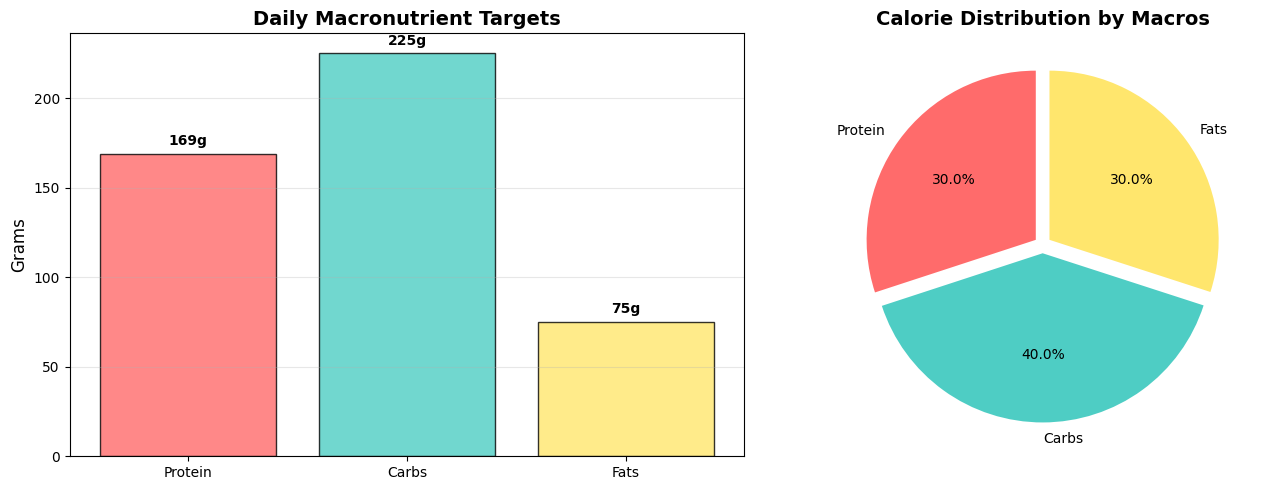


✅ Diet visualization saved!


In [5]:
# Cell 5: Generate Diet Recommendations
print("=" * 50)
print("GENERATING DIET RECOMMENDATIONS")
print("=" * 50)

# Calculate calorie target
calorie_target = get_calorie_target(user_profile['tdee'], user_profile['goal'])
print(f"\nCalorie Target: {calorie_target} calories/day")
print(f"Goal: {user_profile['goal'].replace('_', ' ').title()}")

# Calculate macros
macros = calculate_macros(calorie_target, user_profile['diet_preference'])

print("\n--- Daily Macronutrient Targets ---")
print(f"Calories: {macros['calories']} kcal")
print(f"Protein: {macros['protein']} g")
print(f"Carbs: {macros['carbs']} g")
print(f"Fats: {macros['fats']} g")

# Visualize macros
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
nutrients = ['Protein', 'Carbs', 'Fats']
amounts = [macros['protein'], macros['carbs'], macros['fats']]
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D']

axes[0].bar(nutrients, amounts, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Grams', fontsize=12)
axes[0].set_title('Daily Macronutrient Targets', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(amounts):
    axes[0].text(i, v + 5, str(v) + 'g', ha='center', fontweight='bold')

# Pie chart
calorie_breakdown = [
    macros['protein'] * 4,
    macros['carbs'] * 4,
    macros['fats'] * 9
]
axes[1].pie(calorie_breakdown, labels=nutrients, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Calorie Distribution by Macros', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/plots/diet_macros.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Diet visualization saved!")


In [6]:
# Cell 6: Sample Meal Plan
print("=" * 50)
print("SAMPLE MEAL PLAN")
print("=" * 50)

# Calculate meal-wise calorie distribution
breakfast_cal = round(calorie_target * 0.30)
lunch_cal = round(calorie_target * 0.35)
dinner_cal = round(calorie_target * 0.30)
snack_cal = round(calorie_target * 0.05)

meal_plan = {
    'Breakfast': {
        'calories': breakfast_cal,
        'foods': [
            'Oatmeal with fruits and nuts (1 cup)',
            'Greek yogurt (150g)',
            'Boiled eggs (2)',
            'Green tea'
        ]
    },
    'Lunch': {
        'calories': lunch_cal,
        'foods': [
            'Grilled chicken breast (150g)',
            'Brown rice (1 cup)',
            'Mixed vegetables (200g)',
            'Green salad with olive oil'
        ]
    },
    'Dinner': {
        'calories': dinner_cal,
        'foods': [
            'Baked fish (150g)',
            'Quinoa (1 cup)',
            'Steamed broccoli (150g)',
            'Sweet potato (100g)'
        ]
    },
    'Snacks': {
        'calories': snack_cal,
        'foods': [
            'Mixed nuts (30g)',
            'Apple or banana',
            'Protein shake'
        ]
    }
}

print("\n📋 DAILY MEAL PLAN")
print(f"Total Calories: {calorie_target} kcal")
print(f"Goal: {user_profile['goal'].replace('_', ' ').title()}\n")

for meal, details in meal_plan.items():
    print(f"\n{meal.upper()} (~{details['calories']} kcal)")
    print("-" * 40)
    for food in details['foods']:
        print(f"  • {food}")

print("\n" + "=" * 50)
print("💡 NUTRITION TIPS:")
print("  • Drink at least 8 glasses of water daily")
print("  • Avoid processed and sugary foods")
print("  • Eat every 3-4 hours to maintain metabolism")
print("  • Include protein in every meal")
print("=" * 50)


SAMPLE MEAL PLAN

📋 DAILY MEAL PLAN
Total Calories: 2249 kcal
Goal: Weight Loss


BREAKFAST (~675 kcal)
----------------------------------------
  • Oatmeal with fruits and nuts (1 cup)
  • Greek yogurt (150g)
  • Boiled eggs (2)
  • Green tea

LUNCH (~787 kcal)
----------------------------------------
  • Grilled chicken breast (150g)
  • Brown rice (1 cup)
  • Mixed vegetables (200g)
  • Green salad with olive oil

DINNER (~675 kcal)
----------------------------------------
  • Baked fish (150g)
  • Quinoa (1 cup)
  • Steamed broccoli (150g)
  • Sweet potato (100g)

SNACKS (~112 kcal)
----------------------------------------
  • Mixed nuts (30g)
  • Apple or banana
  • Protein shake

💡 NUTRITION TIPS:
  • Drink at least 8 glasses of water daily
  • Avoid processed and sugary foods
  • Eat every 3-4 hours to maintain metabolism
  • Include protein in every meal


In [7]:
# Cell 7: Generate Exercise Recommendations
print("=" * 50)
print("GENERATING EXERCISE RECOMMENDATIONS")
print("=" * 50)

def get_fitness_level(bmi, age):
    """Determine fitness level"""
    if bmi > 30 or age > 60:
        return 'Beginner'
    elif bmi > 25:
        return 'Intermediate'
    else:
        return 'Advanced'

def get_exercise_plan(goal, fitness_level):
    """Get exercise recommendations based on goal"""
    
    exercises = {
        'weight_loss': {
            'Beginner': [
                {'name': 'Brisk Walking', 'duration': '30 min', 'calories': '150-200'},
                {'name': 'Cycling', 'duration': '20 min', 'calories': '150-250'},
                {'name': 'Swimming', 'duration': '20 min', 'calories': '200-300'},
                {'name': 'Bodyweight Squats', 'sets': '3 x 10', 'calories': '50-80'},
                {'name': 'Light Yoga', 'duration': '20 min', 'calories': '80-120'}
            ],
            'Intermediate': [
                {'name': 'Jogging', 'duration': '30 min', 'calories': '250-350'},
                {'name': 'Cycling', 'duration': '30 min', 'calories': '250-400'},
                {'name': 'Jump Rope', 'duration': '15 min', 'calories': '150-250'},
                {'name': 'Burpees', 'sets': '3 x 12', 'calories': '100-150'},
                {'name': 'Mountain Climbers', 'sets': '3 x 15', 'calories': '80-120'}
            ],
            'Advanced': [
                {'name': 'Running', 'duration': '40 min', 'calories': '400-600'},
                {'name': 'HIIT Training', 'duration': '30 min', 'calories': '400-500'},
                {'name': 'Cycling (Fast)', 'duration': '45 min', 'calories': '400-600'},
                {'name': 'Box Jumps', 'sets': '4 x 15', 'calories': '150-200'},
                {'name': 'Sprint Intervals', 'duration': '20 min', 'calories': '300-400'}
            ]
        },
        'muscle_gain': {
            'Beginner': [
                {'name': 'Push-ups', 'sets': '3 x 10', 'type': 'Chest'},
                {'name': 'Bodyweight Squats', 'sets': '3 x 15', 'type': 'Legs'},
                {'name': 'Planks', 'duration': '3 x 30s', 'type': 'Core'},
                {'name': 'Lunges', 'sets': '3 x 10 each', 'type': 'Legs'},
                {'name': 'Dumbbell Rows', 'sets': '3 x 12', 'type': 'Back'}
            ],
            'Intermediate': [
                {'name': 'Bench Press', 'sets': '4 x 10', 'type': 'Chest'},
                {'name': 'Squats (Weighted)', 'sets': '4 x 12', 'type': 'Legs'},
                {'name': 'Deadlifts', 'sets': '4 x 8', 'type': 'Back'},
                {'name': 'Shoulder Press', 'sets': '3 x 10', 'type': 'Shoulders'},
                {'name': 'Pull-ups', 'sets': '3 x 8', 'type': 'Back'}
            ],
            'Advanced': [
                {'name': 'Barbell Bench Press', 'sets': '5 x 8', 'type': 'Chest'},
                {'name': 'Heavy Squats', 'sets': '5 x 5', 'type': 'Legs'},
                {'name': 'Deadlifts (Heavy)', 'sets': '5 x 5', 'type': 'Back'},
                {'name': 'Military Press', 'sets': '4 x 8', 'type': 'Shoulders'},
                {'name': 'Weighted Pull-ups', 'sets': '4 x 8', 'type': 'Back'}
            ]
        },
        'maintenance': {
            'Beginner': [
                {'name': 'Walking', 'duration': '30 min', 'type': 'Cardio'},
                {'name': 'Yoga', 'duration': '30 min', 'type': 'Flexibility'},
                {'name': 'Light Stretching', 'duration': '15 min', 'type': 'Flexibility'},
                {'name': 'Bodyweight Exercises', 'duration': '20 min', 'type': 'Strength'},
                {'name': 'Swimming', 'duration': '20 min', 'type': 'Cardio'}
            ],
            'Intermediate': [
                {'name': 'Jogging', 'duration': '30 min', 'type': 'Cardio'},
                {'name': 'Strength Training', 'duration': '40 min', 'type': 'Strength'},
                {'name': 'Cycling', 'duration': '30 min', 'type': 'Cardio'},
                {'name': 'Yoga/Pilates', 'duration': '30 min', 'type': 'Flexibility'},
                {'name': 'Swimming', 'duration': '30 min', 'type': 'Cardio'}
            ],
            'Advanced': [
                {'name': 'Running', 'duration': '45 min', 'type': 'Cardio'},
                {'name': 'Weight Training', 'duration': '60 min', 'type': 'Strength'},
                {'name': 'Cycling', 'duration': '45 min', 'type': 'Cardio'},
                {'name': 'Sports (Tennis/Basketball)', 'duration': '60 min', 'type': 'Mixed'},
                {'name': 'Swimming', 'duration': '45 min', 'type': 'Cardio'}
            ]
        }
    }
    
    return exercises.get(goal, exercises['maintenance']).get(fitness_level, [])

# Determine fitness level
fitness_level = get_fitness_level(user_profile['bmi'], user_profile['age'])
print(f"\nFitness Level: {fitness_level}")
print(f"Based on BMI: {user_profile['bmi']}, Age: {user_profile['age']}")

# Get exercise recommendations
exercise_plan = get_exercise_plan(user_profile['goal'], fitness_level)

# Workout frequency
workout_days = {'Beginner': 3, 'Intermediate': 4, 'Advanced': 5}
days_per_week = workout_days[fitness_level]

print(f"\n📋 WEEKLY EXERCISE PLAN")
print(f"Workout Days: {days_per_week} days/week")
print(f"Rest Days: {7 - days_per_week} days/week")
print(f"Session Duration: {'20-30 min' if fitness_level == 'Beginner' else '30-45 min' if fitness_level == 'Intermediate' else '45-60 min'}")

print("\n--- Recommended Exercises ---")
for i, exercise in enumerate(exercise_plan, 1):
    print(f"\n{i}. {exercise['name']}")
    for key, value in exercise.items():
        if key != 'name':
            print(f"   {key.title()}: {value}")

print("\n✅ Exercise recommendations generated!")


GENERATING EXERCISE RECOMMENDATIONS

Fitness Level: Intermediate
Based on BMI: 27.76, Age: 35

📋 WEEKLY EXERCISE PLAN
Workout Days: 4 days/week
Rest Days: 3 days/week
Session Duration: 30-45 min

--- Recommended Exercises ---

1. Jogging
   Duration: 30 min
   Calories: 250-350

2. Cycling
   Duration: 30 min
   Calories: 250-400

3. Jump Rope
   Duration: 15 min
   Calories: 150-250

4. Burpees
   Sets: 3 x 12
   Calories: 100-150

5. Mountain Climbers
   Sets: 3 x 15
   Calories: 80-120

✅ Exercise recommendations generated!


WEEKLY EXERCISE SCHEDULE

       Day Activity
   Monday  Workout
  Tuesday  Workout
Wednesday     Rest
 Thursday  Workout
   Friday     Rest
 Saturday  Workout
   Sunday     Rest


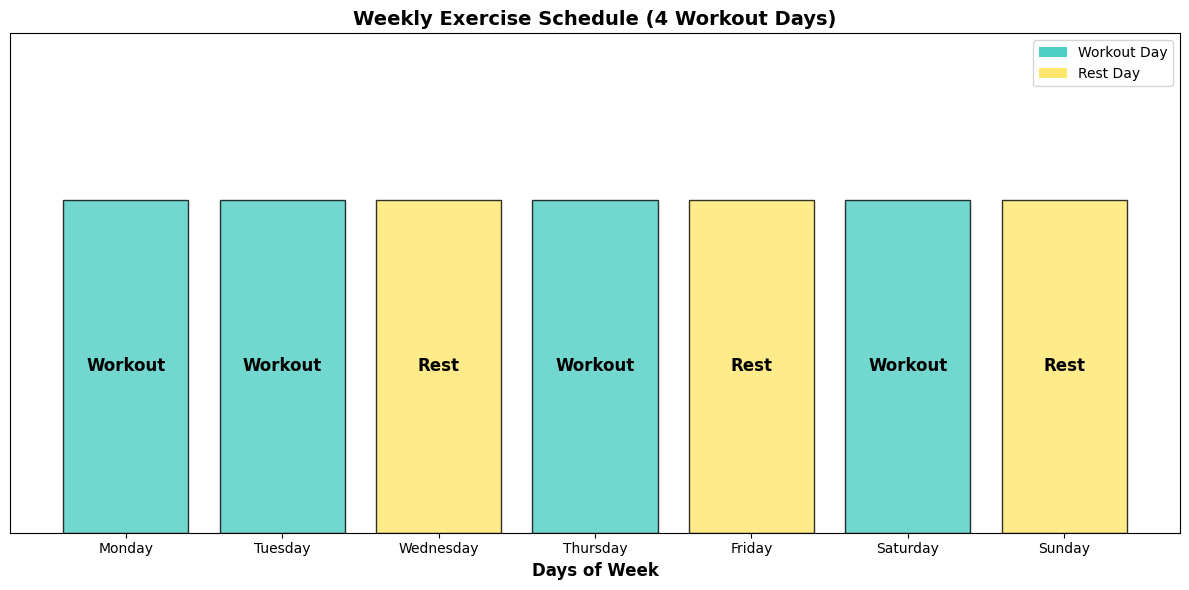


✅ Exercise schedule visualization saved!


In [8]:
# Cell 8: Visualize Weekly Exercise Schedule
print("=" * 50)
print("WEEKLY EXERCISE SCHEDULE")
print("=" * 50)

# Create weekly schedule
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
schedule = []

if days_per_week == 3:
    activities = ['Workout', 'Rest', 'Workout', 'Rest', 'Workout', 'Rest', 'Rest']
elif days_per_week == 4:
    activities = ['Workout', 'Workout', 'Rest', 'Workout', 'Rest', 'Workout', 'Rest']
else:
    activities = ['Workout', 'Workout', 'Workout', 'Rest', 'Workout', 'Workout', 'Rest']

schedule_df = pd.DataFrame({
    'Day': days,
    'Activity': activities
})

print("\n", schedule_df.to_string(index=False))

# Visualize schedule
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#4ECDC4' if activity == 'Workout' else '#FFE66D' for activity in activities]
bars = ax.bar(days, [1]*7, color=colors, edgecolor='black', alpha=0.8)

ax.set_ylim(0, 1.5)
ax.set_yticks([])
ax.set_xlabel('Days of Week', fontsize=12, fontweight='bold')
ax.set_title(f'Weekly Exercise Schedule ({days_per_week} Workout Days)', 
             fontsize=14, fontweight='bold')

# Add labels on bars
for i, (day, activity) in enumerate(zip(days, activities)):
    ax.text(i, 0.5, activity, ha='center', va='center', 
            fontsize=12, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4ECDC4', label='Workout Day'),
    Patch(facecolor='#FFE66D', label='Rest Day')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('../results/plots/exercise_schedule.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Exercise schedule visualization saved!")


In [9]:
# Cell 9: Health Risk Prediction
print("=" * 50)
print("HEALTH RISK PREDICTION")
print("=" * 50)

# Prepare user data for prediction (must match training features)
# Note: Adjust these features based on what your model was trained on
user_features = {
    'Pregnancies': 0,  # Default for male
    'Glucose': user_profile['glucose'],
    'BloodPressure': user_profile['blood_pressure'],
    'SkinThickness': user_profile['skin_thickness'],
    'Insulin': user_profile['insulin'],
    'BMI': user_profile['bmi'],
    'DiabetesPedigreeFunction': 0.5,  # Default
    'Age': user_profile['age']
}

# Add any additional features that were created during training
# (You may need to adjust this based on your actual training features)

try:
    # Create feature DataFrame
    feature_df = pd.DataFrame([user_features])
    
    # Scale features
    features_scaled = scaler.transform(feature_df)
    
    # Predict
    prediction = model.predict(features_scaled)[0]
    probability = model.predict_proba(features_scaled)[0]
    
    risk_status = 'High Risk (Diabetes Detected)' if prediction == 1 else 'Low Risk (No Diabetes)'
    risk_percentage = probability[1] * 100
    
    print(f"\n🏥 HEALTH RISK ASSESSMENT")
    print(f"Status: {risk_status}")
    print(f"Risk Probability: {risk_percentage:.2f}%")
    
    # Visualize risk
    fig, ax = plt.subplots(figsize=(10, 6))
    
    labels = ['Low Risk', 'High Risk']
    sizes = [probability[0] * 100, probability[1] * 100]
    colors = ['#90EE90', '#FF6B6B']
    explode = (0, 0.1) if prediction == 1 else (0.1, 0)
    
    ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_title('Health Risk Assessment', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../results/plots/health_risk_assessment.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Health risk visualization saved!")
    
except Exception as e:
    print(f"⚠️ Could not predict health risk: {e}")
    print("Note: Make sure user features match training features")


HEALTH RISK PREDICTION
⚠️ Could not predict health risk: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Age_BMI
- Age_Group_Encoded
- BMI_Category_Encoded
- BP_Category_Encoded
- Glucose_BMI
- ...

Note: Make sure user features match training features


In [10]:
# Cell 10: Generate Complete Recommendation Report
print("=" * 50)
print("COMPLETE RECOMMENDATION REPORT")
print("=" * 50)

report = {
    'User Information': {
        'Name': user_profile['name'],
        'Age': user_profile['age'],
        'Gender': user_profile['gender'],
        'Weight': f"{user_profile['weight']} kg",
        'Height': f"{user_profile['height']} cm",
        'BMI': user_profile['bmi'],
        'Fitness Level': fitness_level
    },
    'Metabolic Data': {
        'BMR': f"{user_profile['bmr']} cal/day",
        'TDEE': f"{user_profile['tdee']} cal/day",
        'Calorie Target': f"{calorie_target} cal/day",
        'Goal': user_profile['goal'].replace('_', ' ').title()
    },
    'Nutrition Plan': {
        'Daily Calories': f"{macros['calories']} kcal",
        'Protein': f"{macros['protein']} g",
        'Carbohydrates': f"{macros['carbs']} g",
        'Fats': f"{macros['fats']} g",
        'Diet Type': user_profile['diet_preference'].title()
    },
    'Exercise Plan': {
        'Workout Days': f"{days_per_week} days/week",
        'Rest Days': f"{7 - days_per_week} days/week",
        'Session Duration': '20-30 min' if fitness_level == 'Beginner' else '30-45 min' if fitness_level == 'Intermediate' else '45-60 min',
        'Primary Focus': user_profile['goal'].replace('_', ' ').title()
    }
}

print("\n📋 PERSONALIZED HEALTH & FITNESS REPORT")
print("=" * 60)

for section, data in report.items():
    print(f"\n{section.upper()}")
    print("-" * 60)
    for key, value in data.items():
        print(f"{key:.<25} {value}")

# Save report as CSV
report_flat = {}
for section, data in report.items():
    for key, value in data.items():
        report_flat[f"{section}_{key}"] = value

report_df = pd.DataFrame([report_flat])
report_df.to_csv('../results/predictions/user_recommendation_report.csv', index=False)

print("\n✅ Report saved to results/predictions/user_recommendation_report.csv")


COMPLETE RECOMMENDATION REPORT

📋 PERSONALIZED HEALTH & FITNESS REPORT

USER INFORMATION
------------------------------------------------------------
Name..................... John Doe
Age...................... 35
Gender................... Male
Weight................... 85 kg
Height................... 175 cm
BMI...................... 27.76
Fitness Level............ Intermediate

METABOLIC DATA
------------------------------------------------------------
BMR...................... 1773.75 cal/day
TDEE..................... 2749.31 cal/day
Calorie Target........... 2249 cal/day
Goal..................... Weight Loss

NUTRITION PLAN
------------------------------------------------------------
Daily Calories........... 2249 kcal
Protein.................. 169 g
Carbohydrates............ 225 g
Fats..................... 75 g
Diet Type................ Balanced

EXERCISE PLAN
------------------------------------------------------------
Workout Days............. 4 days/week
Rest Days...............

In [11]:
# Cell 11: Save Sample Recommendations
print("=" * 50)
print("SAVING RECOMMENDATIONS")
print("=" * 50)

# Save meal plan
meal_plan_data = []
for meal, details in meal_plan.items():
    for food in details['foods']:
        meal_plan_data.append({
            'Meal': meal,
            'Calories': details['calories'],
            'Food': food
        })

meal_plan_df = pd.DataFrame(meal_plan_data)
meal_plan_df.to_csv('../results/predictions/sample_meal_plan.csv', index=False)
print("✅ Saved: results/predictions/sample_meal_plan.csv")

# Save exercise plan
exercise_df = pd.DataFrame(exercise_plan)
exercise_df.to_csv('../results/predictions/sample_exercise_plan.csv', index=False)
print("✅ Saved: results/predictions/sample_exercise_plan.csv")

# Save weekly schedule
schedule_df.to_csv('../results/predictions/weekly_schedule.csv', index=False)
print("✅ Saved: results/predictions/weekly_schedule.csv")

print("\n✅ All recommendations saved!")


SAVING RECOMMENDATIONS
✅ Saved: results/predictions/sample_meal_plan.csv
✅ Saved: results/predictions/sample_exercise_plan.csv
✅ Saved: results/predictions/weekly_schedule.csv

✅ All recommendations saved!


In [12]:
# Cell 12: Final Summary
print("\n" + "=" * 70)
print("PHASE 4 COMPLETE: DIET & EXERCISE RECOMMENDATIONS")
print("=" * 70)

print("\n✅ Completed Tasks:")
print("   1. ✓ Loaded trained model")
print("   2. ✓ Created user profile")
print("   3. ✓ Calculated metabolic rates (BMR, TDEE)")
print("   4. ✓ Generated personalized diet plan")
print("   5. ✓ Calculated macronutrient targets")
print("   6. ✓ Created sample meal plan")
print("   7. ✓ Generated exercise recommendations")
print("   8. ✓ Created weekly workout schedule")
print("   9. ✓ Predicted health risk")
print("   10. ✓ Generated complete report")

print("\n📁 Files Generated:")
print("   - results/plots/diet_macros.png")
print("   - results/plots/exercise_schedule.png")
print("   - results/plots/health_risk_assessment.png")
print("   - results/predictions/user_recommendation_report.csv")
print("   - results/predictions/sample_meal_plan.csv")
print("   - results/predictions/sample_exercise_plan.csv")
print("   - results/predictions/weekly_schedule.csv")

print(f"\n👤 User: {user_profile['name']}")
print(f"🎯 Goal: {user_profile['goal'].replace('_', ' ').title()}")
print(f"🍽️ Daily Calories: {calorie_target} kcal")
print(f"🏋️ Workout Days: {days_per_week}/week")

print("\n🚀 Ready for Phase 5: Streamlit UI!")



PHASE 4 COMPLETE: DIET & EXERCISE RECOMMENDATIONS

✅ Completed Tasks:
   1. ✓ Loaded trained model
   2. ✓ Created user profile
   3. ✓ Calculated metabolic rates (BMR, TDEE)
   4. ✓ Generated personalized diet plan
   5. ✓ Calculated macronutrient targets
   6. ✓ Created sample meal plan
   7. ✓ Generated exercise recommendations
   8. ✓ Created weekly workout schedule
   9. ✓ Predicted health risk
   10. ✓ Generated complete report

📁 Files Generated:
   - results/plots/diet_macros.png
   - results/plots/exercise_schedule.png
   - results/plots/health_risk_assessment.png
   - results/predictions/user_recommendation_report.csv
   - results/predictions/sample_meal_plan.csv
   - results/predictions/sample_exercise_plan.csv
   - results/predictions/weekly_schedule.csv

👤 User: John Doe
🎯 Goal: Weight Loss
🍽️ Daily Calories: 2249 kcal
🏋️ Workout Days: 4/week

🚀 Ready for Phase 5: Streamlit UI!
